In [2]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import os

# ------------------------------
# CONFIGURATION
# ------------------------------

runs = ["0_6_200_ASC"]#, "06", "07", "08"]

file_pattern = "relative_uplift_timeseries_{}.csv"
depth_limit = 0.15         # meters
fly_out_value = 0.151       # value to assign once a block flies out
half_block_value = 0.0     # value to assign to half blocks (odd columns)

output_suffix = "_corrected.csv"

# ------------------------------
# CORRECT CSVs
# ------------------------------

for run in runs:
    csv_path = file_pattern.format(run)
    corrected_path = csv_path.replace(".csv", output_suffix)

    print(f"\n=== Correcting {csv_path} ===")

    # Load CSV
    df = pd.read_csv(csv_path)

    # Detect time columns automatically
    if df.columns[0].lower() == "step":
        time_cols = list(df.columns[:2])
        data_cols = list(df.columns[2:])
    else:
        time_cols = list(df.columns[:1])
        data_cols = list(df.columns[1:])

    # --------------------------------------------------
    # Calculate cumulative time if Step and StepTime exist
    # --------------------------------------------------

    if df.columns[0].lower() == "step":
        step_col = df.columns[0]
        step_time_col = df.columns[1]

        df[step_time_col] = pd.to_numeric(df[step_time_col], errors="coerce")

        cumulative_time = []
        time_offset = 0.0

        for step_name, group in df.groupby(step_col, sort=False):
            times = group[step_time_col]
            cumulative_times = times + time_offset
            cumulative_time.extend(cumulative_times)
            time_offset = cumulative_times.iloc[-1]

        df["CumulativeTime"] = cumulative_time

    # --------------------------------------------------
    # Check and correct uplift data
    # --------------------------------------------------

    data_values = df[data_cols].values.copy()

    # Boolean mask: True → block has flown out
    has_flown_out = np.zeros(len(data_cols), dtype=bool)

    for i in range(data_values.shape[0]):
        for j in range(data_values.shape[1]):
            if has_flown_out[j]:
                data_values[i, j] = fly_out_value
            else:
                val = data_values[i, j]
                if not np.isnan(val) and val > depth_limit:
                    has_flown_out[j] = True
                    data_values[i, j] = fly_out_value

    # --------------------------------------------------
    # Replace half blocks (odd-numbered columns)
    # --------------------------------------------------

    # Note: enumerate starting from 1 because user considers col 1, 3, 5 etc. as odd
    for idx, col in enumerate(data_cols, start=1):
        if idx % 2 == 1:
            # Overwrite entire column for half blocks
            data_values[:, idx - 1] = half_block_value

    # Create corrected DataFrame
    corrected_parts = [df[time_cols]]

    if "CumulativeTime" in df.columns:
        corrected_parts.append(df[["CumulativeTime"]])

    corrected_parts.append(pd.DataFrame(data_values, columns=data_cols))

    df_corrected = pd.concat(corrected_parts, axis=1)

    # Save corrected file
    df_corrected.to_csv(corrected_path, index=False)
    print(f"✅ Saved corrected file: {corrected_path}")



=== Correcting relative_uplift_timeseries_0_6_200_ASC.csv ===
✅ Saved corrected file: relative_uplift_timeseries_0_6_200_ASC_corrected.csv


Grid width: 4.900 m
MWL (along slope): 14.10 m
ℹ️ Time 200.00 s is during gravity loading or after waves.


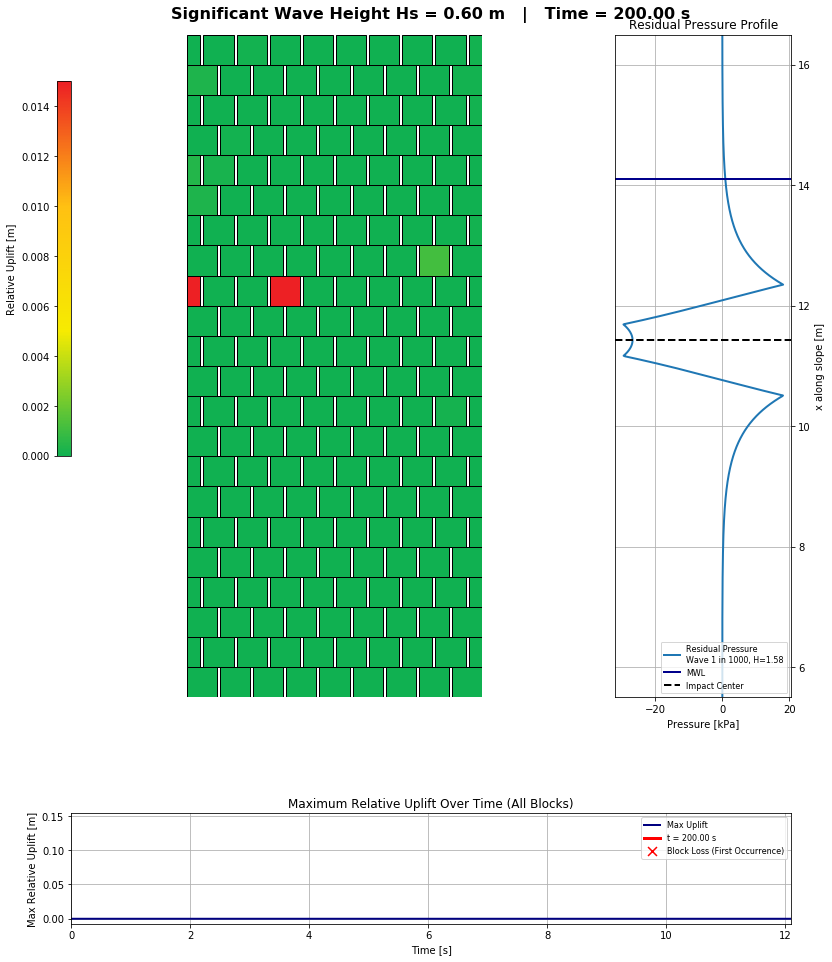

✅ Finished plotting block grid with uplift and residual pressure.

📊 Top 5 most uplifted blocks at t = 200.00 s:
  B-9-1: 0.066 m
  B-8-8: 0.001 m
  B-5-1: 0.000 m
  B-2-1: 0.000 m
  B-6-1: 0.000 m


In [6]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve
from mpl_toolkits.axes_grid1 import make_axes_locatable


# --- Settings ---
fly_out_value = 0.151
target_time = 200   # time in seconds to visualize
csv_path = 'relative_uplift_timeseries_0_6_200_ASC_corrected.csv'
df_uplift = pd.read_csv(csv_path)

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0

grid_width = (9 * full_w) + (8 * horizontal_spacing)
print(f"Grid width: {grid_width:.3f} m")

rows = 22

# ------------------------------
# Load uplift data
# ------------------------------

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]

# Round times for matching
df_uplift[time_col] = df_uplift[time_col].round(2)

# Extract data for plotting the block grid
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]
if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")

block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
block_data = row_df[block_cols].iloc[0]

# Normalize color for uplift values
norm = plt.Normalize(vmin=0, vmax=0.015)

# Custom colormap
colors = ["#10b151", "#f6eb01", "#ffc112", "#ed2024"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)
no_data_color = "lightgray"

# ------------------------------
# Simulate residual profiles
# ------------------------------

Hs = 0.6
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
print(f"MWL (along slope): {x_mwl:.2f} m")

block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

wave_to_plot = list(residual_profiles.keys())[0]

active_wave = None
total_waves = 5
pulse_interval = 2.0
gravity_time = 2.0

for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    print(f"✅ Time {target_time:.2f} s belongs to {wave_name}")
else:
    print(f"ℹ️ Time {target_time:.2f} s is during gravity loading or after waves.")

# ------------------------------
# Plotting
# ------------------------------

fig = plt.figure(figsize=(10, 13))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1],
    wspace=0.05,
    hspace=0.3
)

# --- Top left: block grid ---
ax_grid = fig.add_subplot(gs[0, 0])

for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [
            (full_w, f"B-{row_num}-{col}") for col in range(1, 10)
        ]

    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            if np.isnan(value):
                color = no_data_color
            else:
                color = cmap(norm(value))
        else:
            color = no_data_color

        rect = patches.Rectangle(
            (x_pos, current_y),
            block_w, full_h,
            edgecolor='black',
            facecolor=color,
            linewidth=1
        )
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing

ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar (taller and higher)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift [m]')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])

if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = wave_to_plot
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

residual_vals_kPa = residual_vals / 1000.0

ax_side.plot(
    residual_vals_kPa,
    x,
    color='#1f77b4',
    linewidth=2,
    label=f"Residual Pressure\n{wave_name}"
)
ax_side.axhline(
    x_mwl,
    color='darkblue',
    linestyle='-',
    linewidth=2,
    label='MWL'
)
ax_side.axhline(
    x_center,
    color='black',
    linestyle='--',
    linewidth=2,
    label='Impact Center'
)
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right', fontsize=8)

# --- Bottom: max uplift over time ---
ax_uplift = fig.add_subplot(gs[1, :])

block_data_all = df_uplift[block_cols].copy()

fly_out_mask = (block_data_all == fly_out_value)
block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)

max_uplift = block_data_cleaned.max(axis=1)

first_loss_times = []
for col in block_cols:
    fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
    if fly_out_indices:
        first_idx = fly_out_indices[0]
        first_loss_times.append(df_uplift.loc[first_idx, time_col])

first_loss_times = sorted(set(first_loss_times))

ax_uplift.plot(
    df_uplift[time_col],
    max_uplift,
    color='navy',
    linewidth=2,
    label='Max Uplift'
)
ax_uplift.axvline(
    target_time,
    color='red',
    linestyle='-',
    linewidth=3,
    label=f"t = {target_time:.2f} s"
)

if len(first_loss_times) > 0:
    cross_y_value = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
    ax_uplift.scatter(
        first_loss_times,
        [cross_y_value] * len(first_loss_times),
        color='red',
        marker='x',
        s=80,
        label='Block Loss (First Occurrence)'
    )

ax_uplift.set_xlabel("Time [s]")
ax_uplift.set_xlim(0, 12.1)
ax_uplift.set_ylabel("Max Relative Uplift [m]")
ax_uplift.set_title("Maximum Relative Uplift Over Time (All Blocks)")
ax_uplift.legend(loc='upper right', fontsize=8)
ax_uplift.grid(True)

# --- Global title ---
fig.suptitle(
    f"Significant Wave Height Hs = {Hs:.2f} m   |   Time = {target_time:.2f} s",
    fontsize=16,
    fontweight="bold"
)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.show()

fig.savefig(csv_path.replace(".csv", "_no_time.png"), dpi=300, bbox_inches='tight')
print("✅ Finished plotting block grid with uplift and residual pressure.")

# --- Print top 5 most uplifted blocks at target_time ---
block_data_clean = block_data.replace(fly_out_value, np.nan)
top_5_blocks = block_data_clean.sort_values(ascending=False).head(5)

print(f"\n📊 Top 5 most uplifted blocks at t = {target_time:.2f} s:")
for block_name, uplift_val in top_5_blocks.items():
    print(f"  {block_name}: {uplift_val:.3f} m")


In [1]:
# -*- coding: utf-8 -*-
# Batch plot "grid + residual + max uplift" for every per-job CSV (Py 2.7)

import os
import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve

# -----------------------------
# User settings
# -----------------------------
target_time = 12.0        # seconds to visualize (nearest match will be used)
fly_out_value = 0.151     # treat as missing

# If empty, uses the folder of this script:
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except:
    SCRIPT_DIR = os.getcwd()

# Pattern that matches the per-job CSVs we produced earlier:
CSV_SUFFIX = '_uplift_downdrift_ALLSTEPS_ALLFRAMES.csv'

# -----------------------------
# Brick layout parameters
# -----------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0
rows = 22

grid_width = (9 * full_w) + (8 * horizontal_spacing)
print("Grid width: %.3f m" % grid_width)

# Color map for uplift
colors = ["#10b151", "#f6eb01", "#ffc112", "#ed2024"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)
no_data_color = "lightgray"
norm = plt.Normalize(vmin=0.0, vmax=0.015)

# -----------------------------
# Residual profile constants (same physics as before)
# -----------------------------
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0.0, 20.0 + dx, dx)
N = len(x)
x_mwl = SWL / tan_beta
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

# Time placement of waves (to map target_time to an active wave index)
total_waves = 5
pulse_interval = 2.0
gravity_time = 2.0

# -----------------------------
# Helpers
# -----------------------------
def extract_hs_from_job(job_basename):
    """
    Extract Hs from names like 'Job-H-0_6_2300_30' or 'Job-H-0_6-1950_2'.
    Returns float or default 0.6 if not found.
    """
    m = re.search(r'Job\-H\-([0-9]_[0-9])', job_basename)
    if m:
        return float(m.group(1).replace('_', '.'))
    return 0.6

def read_uplift_df(csv_path):
    """
    Read per-job CSV (Job, Step, FrameIndex, Time, uplift_B-..., sliding_B-...).
    Return (df_uplift, time_col, block_cols) where df_uplift has columns:
      time_col='Time', and block columns named 'B-...' (values are uplifts).
    """
    df = pd.read_csv(csv_path)
    # Identify time column
    time_col = 'Time' if 'Time' in df.columns else df.columns[0]
    # Keep only uplift columns and rename: uplift_B-1-1 -> B-1-1
    uplift_cols = [c for c in df.columns if c.startswith('uplift_B-')]
    rename_map = dict((c, c.replace('uplift_', '')) for c in uplift_cols)
    df_uplift = df[[time_col] + uplift_cols].copy()
    df_uplift.rename(columns=rename_map, inplace=True)
    block_cols = [c.replace('uplift_', '') for c in uplift_cols]
    return df_uplift, time_col, block_cols

def nearest_time_row(df_uplift, time_col, target):
    """Return the row (as Series) whose time is closest to target."""
    tvals = df_uplift[time_col].values.astype(float)
    idx = int(np.argmin(np.abs(tvals - float(target))))
    return df_uplift.iloc[idx]

def simulate_residual_profiles(Hs):
    """
    Build residual profiles for 5 extreme waves (Rayleigh top 1..5 in 1000),
    return (residual_profiles, impact_centers, wave_names).
    """
    sigma = Hs / np.sqrt(2.0)
    exceed_probs = np.arange(1, 6, 1) / 1000.0
    wave_heights = sigma * np.sqrt(-2.0 * np.log(exceed_probs))

    residual_profiles = {}
    impact_centers = {}
    wave_names = []

    for i, H_wave in enumerate(wave_heights):
        Tm_1_0 = Tp / 1.1
        L_m_1_0 = (g * (Tm_1_0 ** 2)) / (2.0 * np.pi)
        xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
        if xi < 3.0:
            z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1))
            x_center = (SWL - z_SWL) / tan_beta
        else:
            # No impact (as in your earlier logic)
            x_center = (SWL - 0.0) / tan_beta

        w_base = (7.0 / 6.0) * H_wave
        w_top  = (1.0 / 3.0) * H_wave
        x_left_base  = x_center - w_base / 2.0
        x_right_base = x_center + w_base / 2.0
        x_left_top   = x_center - w_top  / 2.0
        x_right_top  = x_center + w_top  / 2.0

        denom = (xi - 0.2) ** 2
        P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
        P_max = P_dimless * rho_w * g * H_wave

        p_vals = np.zeros_like(x)
        # Trapezoid (only if meaningful span)
        for j, xx in enumerate(x):
            if x_left_base <= xx < x_left_top and (x_left_top != x_left_base):
                p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
            elif x_left_top <= xx <= x_right_top:
                p_vals[j] = P_max
            elif x_right_top < xx <= x_right_base and (x_right_base != x_right_top):
                p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

        # Solve filter response
        b_vec = -p_vals.copy()
        b_vec[0]  = 0.0
        b_vec[-1] = 0.0

        A = np.zeros((N, N))
        coeff = (Lambda ** 2) / (dx ** 2)
        for jj in range(1, N - 1):
            A[jj, jj - 1] = coeff
            A[jj, jj]     = -2.0 * coeff - 1.0
            A[jj, jj + 1] = coeff
        A[0, 0]   = 1.0
        A[-1, -1] = 1.0

        phi_F = solve(A, b_vec)
        residual = phi_F - p_vals

        wave_name = "Wave %d in 1000, H=%.2f" % (i + 1, H_wave)
        residual_profiles[wave_name] = residual
        impact_centers[wave_name] = x_center
        wave_names.append(wave_name)

    return residual_profiles, impact_centers, wave_names

def wave_index_for_time(t):
    """Map time to active wave index based on gravity_time and pulse_interval."""
    for wave_idx in range(total_waves):
        t_start = gravity_time + wave_idx * pulse_interval
        t_end = gravity_time + (wave_idx + 1) * pulse_interval
        if (t >= t_start) and (t < t_end):
            return wave_idx
    return None

def plot_one(csv_path):
    # ---- Read and reshape data
    df_uplift, time_col, block_cols = read_uplift_df(csv_path)

    # ---- Choose the time slice closest to target_time
    row = nearest_time_row(df_uplift, time_col, target_time)
    t_sel = float(row[time_col])

    # ---- Pull the single-time block values as a Series, columns 'B-...'
    block_data = row[block_cols]

    # ---- Extract Hs from job name
    job_basename = os.path.splitext(os.path.basename(csv_path))[0]
    # Trim suffix to recover job name for title
    job_name_for_title = job_basename.replace(CSV_SUFFIX.replace('.csv',''), '')
    Hs = extract_hs_from_job(job_basename)

    # ---- Simulate residual profiles for that Hs (as in your script)
    residual_profiles, impact_centers, wave_names = simulate_residual_profiles(Hs)

    # Determine which wave is active for t_sel
    active_idx = wave_index_for_time(t_sel)
    if active_idx is not None:
        wave_name = wave_names[active_idx]
    else:
        wave_name = wave_names[0]  # fallback

    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
    residual_vals_kPa = residual_vals / 1000.0

    # ---- Begin plotting
    fig = plt.figure(figsize=(10, 13))
    gs = gridspec.GridSpec(
        nrows=2, ncols=2,
        width_ratios=[3, 1], height_ratios=[6, 1],
        wspace=0.05, hspace=0.3
    )

    # --- Top left: block grid
    ax_grid = fig.add_subplot(gs[0, 0])

    for row_num in range(1, rows + 1):
        current_y = (rows - row_num) * (full_h + v_spacing)
        is_half = (row_num % 2 == 1)
        if is_half:
            block_sequence = ([(half_w, "B-%d-1" % row_num)] +
                              [(full_w, "B-%d-%d" % (row_num, col)) for col in range(2, 10)] +
                              [(half_w, "B-%d-10" % row_num)])
        else:
            block_sequence = [(full_w, "B-%d-%d" % (row_num, col)) for col in range(1, 10)]

        x_pos = 0.0
        for block_w, block_name in block_sequence:
            if block_name in block_data.index:
                val = block_data[block_name]
                if pd.isnull(val):
                    color = no_data_color
                else:
                    color = cmap(norm(val))
            else:
                color = no_data_color

            rect = patches.Rectangle((x_pos, current_y),
                                     block_w, full_h,
                                     edgecolor='black',
                                     facecolor=color,
                                     linewidth=1)
            ax_grid.add_patch(rect)
            x_pos += block_w + horizontal_spacing

    ax_grid.set_aspect('equal')
    ax_grid.set_xlim(0, grid_width)
    ax_grid.set_ylim(0, rows * full_h)
    ax_grid.axis('off')

    # Colorbar on the left
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
    cbar.set_label('Relative Uplift [m]')
    cbar.ax.yaxis.set_label_position('left')
    cbar.ax.yaxis.set_ticks_position('left')

    # --- Top right: residual pressure profile
    ax_side = fig.add_subplot(gs[0, 1])
    ax_side.plot(residual_vals_kPa, x, color='#1f77b4', linewidth=2, label="Residual Pressure\n%s" % wave_name)
    ax_side.axhline(x_mwl, color='darkblue', linestyle='-', linewidth=2, label='MWL')
    ax_side.axhline(x_center, color='black', linestyle='--', linewidth=2, label='Impact Center')
    ax_side.invert_yaxis()
    ax_side.set_xlabel('Pressure [kPa]')
    ax_side.set_ylabel('x along slope [m]')
    ax_side.set_ylim(5.5, 16.5)
    ax_side.yaxis.tick_right()
    ax_side.yaxis.set_label_position("right")
    ax_side.set_title("Residual Pressure Profile")
    ax_side.grid(True)
    ax_side.legend(loc='lower right', fontsize=8)

    # --- Bottom: max uplift over time
    ax_uplift = fig.add_subplot(gs[1, :])

    # Clean fly-out as NaN, then max over blocks each time row
    block_df_all = df_uplift[block_cols].copy()
    fly_out_mask = (block_df_all == fly_out_value)
    block_df_clean = block_df_all.where(~fly_out_mask, np.nan)
    max_uplift = block_df_clean.max(axis=1)

    # Mark first loss per block by looking for first fly_out occurrence
    first_loss_times = []
    for col in block_cols:
        idxs = np.where(fly_out_mask[col].values)[0].tolist()
        if idxs:
            first_loss_times.append(df_uplift[time_col].iloc[idxs[0]])
    first_loss_times = sorted(set(first_loss_times))

    ax_uplift.plot(df_uplift[time_col], max_uplift, color='navy', linewidth=2, label='Max Uplift')
    ax_uplift.axvline(t_sel, color='red', linestyle='-', linewidth=3, label="t = %.2f s" % t_sel)

    if len(first_loss_times) > 0:
        cross_y = (np.nanmax(max_uplift.values) * 1.1) if np.nanmax(max_uplift.values) > 0 else 0.01
        ax_uplift.scatter(first_loss_times, [cross_y] * len(first_loss_times),
                          color='red', marker='x', s=80, label='Block Loss (First Occurrence)')

    ax_uplift.set_xlabel("Time [s]")
    ax_uplift.set_xlim(0.0, max(df_uplift[time_col].max(), t_sel) * 1.01)
    ax_uplift.set_ylabel("Max Relative Uplift [m]")
    ax_uplift.set_title("Maximum Relative Uplift Over Time (All Blocks)")
    ax_uplift.legend(loc='upper right', fontsize=8)
    ax_uplift.grid(True)

    # --- Global title
    fig.suptitle("Job: %s   |   Hs = %.2f m   |   Time = %.2f s" %
                 (job_name_for_title, Hs, t_sel),
                 fontsize=16, fontweight="bold")

    plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)

    # Save PNG next to CSV
    out_png = csv_path.replace('.csv', '_viz.png')
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    print("Saved:", out_png)
    plt.close(fig)

# -----------------------------
# Run for all matching CSVs
# -----------------------------
def main():
    files = [f for f in os.listdir(SCRIPT_DIR) if f.endswith(CSV_SUFFIX)]
    if not files:
        print("No per-job CSVs found in: %s" % SCRIPT_DIR)
        return
    for f in sorted(files):
        try:
            plot_one(os.path.join(SCRIPT_DIR, f))
        except Exception as e:
            print("Failed plotting for %s : %s" % (f, str(e)))

if __name__ == '__main__':
    main()


Grid width: 4.900 m
Saved: d:\tpennock\GitHub\Thesis_Repository\workfolder\uplift matrix 2\Job-H-0_8_2300_30_uplift_downdrift_ALLSTEPS_ALLFRAMES_viz.png
Saved: d:\tpennock\GitHub\Thesis_Repository\workfolder\uplift matrix 2\Job-H-0_9_2300_30_uplift_downdrift_ALLSTEPS_ALLFRAMES_viz.png
Saved: d:\tpennock\GitHub\Thesis_Repository\workfolder\uplift matrix 2\Job-H-1_0_2300_30_uplift_downdrift_ALLSTEPS_ALLFRAMES_viz.png
Saved: d:\tpennock\GitHub\Thesis_Repository\workfolder\uplift matrix 2\all_jobs_uplift_downdrift_ALLSTEPS_ALLFRAMES_viz.png


In [20]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# -------------------
# User settings
# -------------------
csv_path = "relative_uplift_timeseries_0_6_200_ASC_corrected.csv"

D=0.150
# Uplift thresholds for damage categories [m]
# Format: (min_uplift, max_uplift)
damage_thresholds = {
    "Damage cat. 1": (0.001, 0.25*D),
    "Damage cat. 2": (0.25*D, 0.5*D),
    "Damage cat. 3": (0.5*D, 2),
    "Damage cat. 4": (2, 3),
}

# Which waves to extract (in number of highest waves in 1000)
wave_numbers = [1, 5, 10, 20, 50, 100]

# -------------------
# Load CSV
# -------------------
df = pd.read_csv(csv_path)

# Detect time column
time_col = df.columns[0]
if time_col.lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df.columns else df.columns[1]

block_cols = [c for c in df.columns if c.startswith("B-")]

# -------------------
# Function to assign damage category
# -------------------
def assign_damage_category(uplift_value):
    for cat, (low, high) in damage_thresholds.items():
        if low <= uplift_value <= high:
            return str(list(damage_thresholds.keys()).index(cat) + 1)
    return "-"

# -------------------
# Simulate: pick the time for each N (you may adapt this for your run timing)
# -------------------
# Here I assume you have one "wave" per time step in order
# You may need to adapt this mapping for your simulation data
results = []
for N in wave_numbers:
    # Example: take row N-1 (if sorted in time)
    if N - 1 < len(df):
        row = df.iloc[N - 1]
        max_uplift = row[block_cols].replace(0.151, np.nan).max(skipna=True)  # skip fly-out values
        damage_values = [assign_damage_category(max_uplift) for _ in damage_thresholds]
        results.append([N, round(max_uplift, 2)] + damage_values)
    else:
        results.append([N, "-", "-", "-", "-", "-"])

# -------------------
# Create DataFrame
# -------------------
columns = ["N", "H (m)"] + list(damage_thresholds.keys())
df_table = pd.DataFrame(results, columns=columns)

# -------------------
# Export LaTeX table
# -------------------
latex_str = df_table.to_latex(index=False, escape=False)
print(latex_str)

# Save to file
with open("damage_table.tex", "w") as f:
    f.write(latex_str)

print("✅ LaTeX table saved to damage_table.tex")


\begin{tabular}{rrllll}
\toprule
   N &  H (m) & Damage cat. 1 & Damage cat. 2 & Damage cat. 3 & Damage cat. 4 \\
\midrule
   1 &    0.0 &             - &             - &             - &             - \\
   5 &    0.0 &             - &             - &             - &             - \\
  10 &    0.0 &             - &             - &             - &             - \\
  20 &    0.0 &             - &             - &             - &             - \\
  50 &    0.0 &             - &             - &             - &             - \\
 100 &    0.0 &             - &             - &             - &             - \\
\bottomrule
\end{tabular}

✅ LaTeX table saved to damage_table.tex


In [24]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# -------------------
# User settings
# -------------------
csv_path = "relative_uplift_timeseries_0_6_200_ASC_corrected.csv"

D = 0.150
# Uplift thresholds for damage categories [m]
# Format: (min_uplift, max_uplift)
damage_thresholds = {
    "Damage cat. 1": (0.001, 0.25 * D),
    "Damage cat. 2": (0.25 * D, 0.5 * D),
    "Damage cat. 3": (0.5 * D, 2),
    "Damage cat. 4": (2, 100),
}

# Which waves to extract (in number of highest waves in 1000)
wave_numbers = [1, 5, 10, 20, 50, 100]

# -------------------
# Load CSV
# -------------------
df = pd.read_csv(csv_path)

# Detect time column
time_col = df.columns[0]
if time_col.lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df.columns else df.columns[1]

block_cols = [c for c in df.columns if c.startswith("B-")]

# -------------------
# Function to assign damage category (only one per value)
# -------------------
def assign_damage_category(uplift_value):
    for cat, (low, high) in damage_thresholds.items():
        if low <= uplift_value < high:  # strict upper bound
            return cat
    return None

# -------------------
# Simulate: define waves every 2s starting at 0.5
# -------------------
wave_starts = np.arange(0.5, df[time_col].max(), 2.0)
wave_windows = [(start, start + 2.0) for start in wave_starts]

results = []

for i, N in enumerate(wave_numbers):
    if i < len(wave_windows):
        start, end = wave_windows[i]
        mask = (df[time_col] >= start) & (df[time_col] < end)
        wave_df = df.loc[mask, block_cols]

        if not wave_df.empty:
            max_uplift = wave_df.replace(0.151, np.nan).max().max()  # global max uplift
            cat = assign_damage_category(max_uplift)

            # Fill row with "-" except matching category
            row_values = ["-"] * len(damage_thresholds)
            if cat is not None:
                cat_idx = list(damage_thresholds.keys()).index(cat)
                row_values[cat_idx] = str(cat_idx + 1)

            results.append([N, round(max_uplift, 2)] + row_values)
        else:
            results.append([N, "-", "-", "-", "-", "-"])
    else:
        results.append([N, "-", "-", "-", "-", "-"])

# -------------------
# Create DataFrame
# -------------------
columns = ["N", "H (m)"] + list(damage_thresholds.keys())
df_table = pd.DataFrame(results, columns=columns)

# -------------------
# Export LaTeX table
# -------------------
latex_str = df_table.to_latex(index=False, escape=False)
print(latex_str)

with open("damage_table.tex", "w") as f:
    f.write(latex_str)

print("✅ LaTeX table saved to damage_table.tex")


\begin{tabular}{rrllll}
\toprule
   N &  H (m) & Damage cat. 1 & Damage cat. 2 & Damage cat. 3 & Damage cat. 4 \\
\midrule
   1 &    0.0 &             - &             - &             - &             - \\
   5 &    0.0 &             - &             - &             - &             - \\
  10 &    0.0 &             - &             - &             - &             - \\
  20 &    0.0 &             - &             - &             - &             - \\
  50 &    0.0 &             - &             - &             - &             - \\
 100 &    0.0 &             - &             - &             - &             - \\
\bottomrule
\end{tabular}

✅ LaTeX table saved to damage_table.tex


In [25]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# -------------------
# User settings
# -------------------
csv_path = "relative_uplift_timeseries_0_6_200_ASC_corrected.csv"

D = 0.150
damage_thresholds = {
    "Damage cat. 1": (0.001, 0.25 * D),
    "Damage cat. 2": (0.25 * D, 0.5 * D),
    "Damage cat. 3": (0.5 * D, 2),
    "Damage cat. 4": (2, 3),
}

wave_numbers = [1, 5, 10, 20, 50, 100]

# -------------------
# Load CSV
# -------------------
df = pd.read_csv(csv_path)

time_col = df.columns[0]
if time_col.lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df.columns else df.columns[1]

block_cols = [c for c in df.columns if c.startswith("B-")]

def assign_damage_category(uplift_value):
    for cat, (low, high) in damage_thresholds.items():
        if low <= uplift_value < high:
            return cat
    return None

results = []
top5_for_wave100 = None

for N in wave_numbers:
    wave_time = 0.5 + (N - 1) * 2.0
    idx = (df[time_col] - wave_time).abs().idxmin()
    row = df.loc[idx, block_cols].replace(0.151, np.nan)

    max_uplift = row.max(skipna=True)

    if pd.notna(max_uplift):
        cat = assign_damage_category(max_uplift)

        row_values = ["-"] * len(damage_thresholds)
        if cat is not None:
            cat_idx = list(damage_thresholds.keys()).index(cat)
            row_values[cat_idx] = str(cat_idx + 1)

        results.append([N, round(max_uplift, 2)] + row_values)

        # Store top 5 block values for wave 100
        if N == 100:
            top5_for_wave100 = row.sort_values(ascending=False).head(5)

    else:
        results.append([N, "-", "-", "-", "-", "-"])

columns = ["N", "H (m)"] + list(damage_thresholds.keys())
df_table = pd.DataFrame(results, columns=columns)

# Export LaTeX
latex_str = df_table.to_latex(index=False, escape=False)
print(latex_str)

with open("damage_table.tex", "w") as f:
    f.write(latex_str)

print("✅ LaTeX table saved to damage_table.tex")

# Show top 5 for wave 100
if top5_for_wave100 is not None:
    print("\n🔝 Top 5 block uplifts for wave 100:")
    print(top5_for_wave100)


\begin{tabular}{rrllll}
\toprule
   N &  H (m) & Damage cat. 1 & Damage cat. 2 & Damage cat. 3 & Damage cat. 4 \\
\midrule
   1 &   0.00 &             - &             - &             - &             - \\
   5 &   0.00 &             - &             - &             - &             - \\
  10 &   0.00 &             - &             - &             - &             - \\
  20 &   0.00 &             - &             - &             - &             - \\
  50 &   0.00 &             - &             - &             - &             - \\
 100 &   0.07 &             - &             2 &             - &             - \\
\bottomrule
\end{tabular}

✅ LaTeX table saved to damage_table.tex

🔝 Top 5 block uplifts for wave 100:
B-9-1    0.066176
B-8-8    0.001129
B-5-1    0.000487
B-2-1    0.000430
B-6-1    0.000405
Name: 1985, dtype: float64


In [7]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# -------------------
# User settings
# -------------------
csv_path = "relative_uplift_timeseries_0_6_200_ASC_corrected.csv"

# Uplift thresholds for damage categories [m]
damage_thresholds = {
    "Damage cat. 1": (0.010, 0.015),
    "Damage cat. 2": (0.005, 0.010),
    "Damage cat. 3": (0.002, 0.005),
    "Damage cat. 4": (0.000, 0.002),
}

# Wave ranks to check
wave_numbers = [1, 5, 10, 20, 50, 100]

# Fly-out value
fly_out_value = 0.151

# -------------------
# Load CSV
# -------------------
df = pd.read_csv(csv_path)

# Detect time column
time_col = df.columns[0]
if time_col.lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df.columns else df.columns[1]

block_cols = [c for c in df.columns if c.startswith("B-")]

# -------------------
# Function to assign damage category
# -------------------
def assign_damage_category(uplift_value):
    for cat, (low, high) in damage_thresholds.items():
        if low <= uplift_value <= high:
            return str(list(damage_thresholds.keys()).index(cat) + 1)
    return "-"

# -------------------
# Process table and print top uplifted blocks
# -------------------
results = []
for N in wave_numbers:
    if N - 1 < len(df):
        row = df.iloc[N - 1]
        block_data = row[block_cols].replace(fly_out_value, np.nan)

        # Find max uplift
        max_uplift = block_data.max(skipna=True)

        # Assign damage categories
        damage_values = [assign_damage_category(max_uplift) for _ in damage_thresholds]

        results.append([N, round(max_uplift, 2)] + damage_values)

        # ---- Print top 5 uplifted blocks ----
        top_blocks = block_data.sort_values(ascending=False).head(5)
        print(f"\nWave rank {N}:")
        for block_name, uplift_val in top_blocks.items():
            print(f"  {block_name}: {uplift_val:.3f} m")
    else:
        results.append([N, "-", "-", "-", "-", "-"])

# -------------------
# Create DataFrame
# -------------------
columns = ["N", "H (m)"] + list(damage_thresholds.keys())
df_table = pd.DataFrame(results, columns=columns)

# -------------------
# Export LaTeX table
# -------------------
latex_str = df_table.to_latex(index=False, escape=False)
print("\nLaTeX Table:\n")
print(latex_str)

with open("damage_table.tex", "w") as f:
    f.write(latex_str)

print("\n✅ LaTeX table saved to damage_table.tex")



Wave rank 1:
  B-22-7: 0.000 m
  B-22-1: 0.000 m
  B-18-1: 0.000 m
  B-19-3: 0.000 m
  B-19-10: 0.000 m

Wave rank 5:
  B-1-5: 0.001 m
  B-1-10: 0.001 m
  B-2-5: 0.001 m
  B-3-5: 0.001 m
  B-1-7: 0.001 m

Wave rank 10:
  B-1-7: 0.000 m
  B-2-7: 0.000 m
  B-3-7: 0.000 m
  B-1-5: 0.000 m
  B-4-6: 0.000 m

Wave rank 20:
  B-22-7: 0.000 m
  B-18-1: 0.000 m
  B-19-3: 0.000 m
  B-19-10: 0.000 m
  B-18-9: 0.000 m

Wave rank 50:
  B-9-2: 0.001 m
  B-9-1: 0.001 m
  B-9-6: 0.001 m
  B-8-8: 0.000 m
  B-9-8: 0.000 m

Wave rank 100:
  B-9-6: 0.003 m
  B-9-2: 0.002 m
  B-8-2: 0.002 m
  B-8-6: 0.001 m
  B-8-8: 0.000 m

LaTeX Table:

\begin{tabular}{rrllll}
\toprule
   N &  H (m) & Damage cat. 1 & Damage cat. 2 & Damage cat. 3 & Damage cat. 4 \\
\midrule
   1 &    0.0 &             4 &             4 &             4 &             4 \\
   5 &    0.0 &             4 &             4 &             4 &             4 \\
  10 &    0.0 &             4 &             4 &             4 &             4 \\
  20 & 

In [19]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np

# -------------------
# User settings
# -------------------
csv_path = "relative_uplift_timeseries_0_6_200_ASC_corrected.csv"

# Uplift thresholds for damage categories [m]
damage_thresholds = {
    "Damage cat. 1": (0.010, 0.015),
    "Damage cat. 2": (0.005, 0.010),
    "Damage cat. 3": (0.002, 0.005),
    "Damage cat. 4": (0.000, 0.002),
}

# Wave ranks to check
wave_numbers = [1, 5, 10, 20, 50, 100]

# Fly-out value
fly_out_value = 0.151

# -------------------
# Load CSV
# -------------------
df = pd.read_csv(csv_path)

# Detect time column
time_col = df.columns[0]
if time_col.lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df.columns else df.columns[1]

block_cols = [c for c in df.columns if c.startswith("B-")]

# -------------------
# Function to assign damage category
# -------------------
def assign_damage_category(uplift_value):
    for cat, (low, high) in damage_thresholds.items():
        if low <= uplift_value <= high:
            return str(list(damage_thresholds.keys()).index(cat) + 1)
    return "-"

# -------------------
# Process table and print top uplifted blocks
# -------------------
results = []
for N in wave_numbers:
    if N - 1 < len(df):
        row = df.iloc[N - 1]
        block_data = row[block_cols].replace(fly_out_value, np.nan)

        # Find max uplift
        max_uplift = block_data.max(skipna=True)

        # Assign damage categories
        damage_values = [assign_damage_category(max_uplift) for _ in damage_thresholds]

        results.append([N, round(max_uplift, 2)] + damage_values)

        # ---- Print top 5 uplifted blocks ----
        top_blocks = block_data.sort_values(ascending=False).head(5)
        print(f"\nWave rank {N}:")
        for block_name, uplift_val in top_blocks.items():
            print(f"  {block_name}: {uplift_val:.3f} m")
    else:
        results.append([N, "-", "-", "-", "-", "-"])

# -------------------
# Create DataFrame
# -------------------
columns = ["N", "H (m)"] + list(damage_thresholds.keys())
df_table = pd.DataFrame(results, columns=columns)

# -------------------
# Export LaTeX table
# -------------------
latex_str = df_table.to_latex(index=False, escape=False)
print("\nLaTeX Table:\n")
print(latex_str)

with open("damage_table.tex", "w") as f:
    f.write(latex_str)

print("\n✅ LaTeX table saved to damage_table.tex")



Wave rank 1:
  B-22-7: 0.000 m
  B-22-1: 0.000 m
  B-18-1: 0.000 m
  B-19-3: 0.000 m
  B-19-10: 0.000 m

Wave rank 5:
  B-22-5: 0.000 m
  B-22-9: 0.000 m
  B-22-3: 0.000 m
  B-18-1: 0.000 m
  B-19-3: 0.000 m

Wave rank 10:
  B-22-5: 0.000 m
  B-18-1: 0.000 m
  B-19-3: 0.000 m
  B-19-10: 0.000 m
  B-18-9: 0.000 m

Wave rank 20:
  B-22-1: 0.000 m
  B-9-9: 0.000 m
  B-18-1: 0.000 m
  B-19-3: 0.000 m
  B-19-10: 0.000 m

Wave rank 50:
  B-22-1: 0.000 m
  B-9-9: 0.000 m
  B-18-1: 0.000 m
  B-19-3: 0.000 m
  B-19-10: 0.000 m

Wave rank 100:
  B-22-1: 0.000 m
  B-22-5: 0.000 m
  B-22-7: 0.000 m
  B-22-3: 0.000 m
  B-18-1: 0.000 m

LaTeX Table:

\begin{tabular}{rrllll}
\toprule
   N &  H (m) & Damage cat. 1 & Damage cat. 2 & Damage cat. 3 & Damage cat. 4 \\
\midrule
   1 &    0.0 &             4 &             4 &             4 &             4 \\
   5 &    0.0 &             4 &             4 &             4 &             4 \\
  10 &    0.0 &             4 &             4 &             4 &      

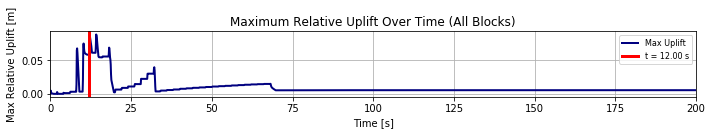


📊 Top 5 most uplifted blocks at t = 12.00 s:
  B-9-8: 0.058 m
  B-9-6: 0.014 m
  B-9-1: 0.001 m
  B-8-6: 0.001 m
  B-8-8: 0.000 m


In [14]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Settings ---
fly_out_value = 0.151
target_time = 12   # time in seconds to visualize
csv_path = 'relative_uplift_timeseries_0_6_200_ASC_corrected.csv'

# Load data
df_uplift = pd.read_csv(csv_path)

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]

# Round times
df_uplift[time_col] = df_uplift[time_col].round(2)

# Identify block columns
block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
block_data_all = df_uplift[block_cols].copy()

# Handle fly-out values
fly_out_mask = (block_data_all == fly_out_value)
block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)

# Calculate max uplift at each time
max_uplift = block_data_cleaned.max(axis=1)

# Identify first loss times for any block
first_loss_times = []
for col in block_cols:
    fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
    if fly_out_indices:
        first_idx = fly_out_indices[0]
        first_loss_times.append(df_uplift.loc[first_idx, time_col])

first_loss_times = sorted(set(first_loss_times))

# --- Plot ---
# Same width as before (10) and height ratio (1/7 of 13 ≈ 1.86)
fig, ax = plt.subplots(figsize=(10, 1.86))

# Plot max uplift over time
ax.plot(df_uplift[time_col], max_uplift, color='navy', linewidth=2, label='Max Uplift')

# Vertical line at target time
ax.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.2f} s")

# Mark first block loss times
if len(first_loss_times) > 0:
    cross_y_value = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
    ax.scatter(first_loss_times, [cross_y_value] * len(first_loss_times),
               color='red', marker='x', s=80, label='Block Loss (First Occurrence)')

# Labels and style
ax.set_xlabel("Time [s]")
ax.set_xlim(0, df_uplift[time_col].max())
ax.set_ylabel("Max Relative Uplift [m]")
ax.set_title("Maximum Relative Uplift Over Time (All Blocks)")
ax.legend(loc='upper right', fontsize=8)
ax.grid(True)

# Save and show
plt.tight_layout()
plt.show()

# --- Print top 5 most uplifted blocks at target_time ---
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]
if not row_df.empty:
    block_data = row_df[block_cols].iloc[0].replace(fly_out_value, np.nan)
    top_5_blocks = block_data.sort_values(ascending=False).head(5)

    print(f"\n📊 Top 5 most uplifted blocks at t = {target_time:.2f} s:")
    for block_name, uplift_val in top_5_blocks.items():
        print(f"  {block_name}: {uplift_val:.3f} m")
else:
    print(f"⛔ No data found for t = {target_time:.2f} s")


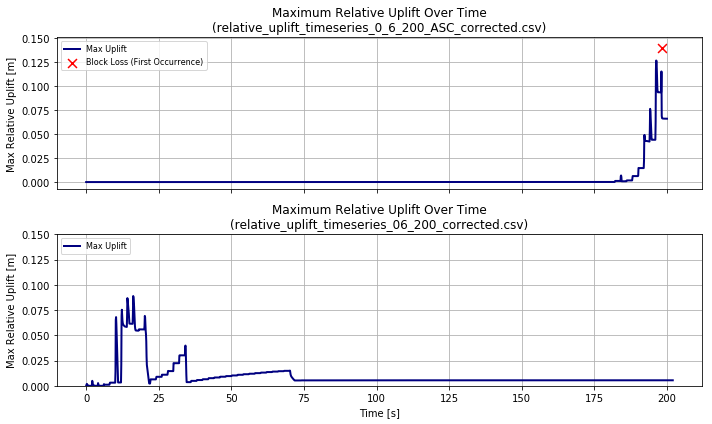

[198.2]


In [11]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Settings ---
fly_out_value = 0.151

csv_path1 = 'relative_uplift_timeseries_0_6_200_ASC_corrected.csv'
csv_path2 = 'relative_uplift_timeseries_06_200_corrected.csv'

def process_csv(csv_path):
    """Reads CSV, processes uplift data, and returns time, max uplift, and first loss times."""
    df_uplift = pd.read_csv(csv_path)

    # Detect time column automatically
    if df_uplift.columns[0].lower() == "step":
        time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
    else:
        time_col = df_uplift.columns[0]

    # Round times
    df_uplift[time_col] = df_uplift[time_col].round(2)

    # Identify block columns
    block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
    block_data_all = df_uplift[block_cols].copy()

    # Handle fly-out values
    fly_out_mask = (block_data_all == fly_out_value)
    block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)

    # Calculate max uplift at each time
    max_uplift = block_data_cleaned.max(axis=1)

    # Identify first loss times
    first_loss_times = []
    for col in block_cols:
        fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
        if fly_out_indices:
            first_idx = fly_out_indices[0]
            first_loss_times.append(df_uplift.loc[first_idx, time_col])
    first_loss_times = sorted(set(first_loss_times))

    return df_uplift[time_col], max_uplift, first_loss_times

# --- Process both CSVs ---
time1, max_uplift1, loss_times1 = process_csv(csv_path1)
time2, max_uplift2, loss_times2 = process_csv(csv_path2)

# --- Plot ---
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(10, 6),  # double height of original single plot
    sharex=True
)

# Top subplot
axes[0].plot(time1, max_uplift1, color='navy', linewidth=2, label='Max Uplift')
if len(loss_times1) > 0:
    cross_y_value = max_uplift1.max() * 1.1 if max_uplift1.max() > 0 else 0.01
    axes[0].scatter(loss_times1, [cross_y_value] * len(loss_times1),
                    color='red', marker='x', s=80, label='Block Loss (First Occurrence)')
axes[0].set_ylabel("Max Relative Uplift [m]")
axes[0].set_title(f"Maximum Relative Uplift Over Time\n({csv_path1})")
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(True)

# Bottom subplot
axes[1].plot(time2, max_uplift2, color='navy', linewidth=2, label='Max Uplift')
if len(loss_times2) > 0:
    cross_y_value = max_uplift2.max() * 1.1 if max_uplift2.max() > 0 else 0.01
    axes[1].scatter(loss_times2, [cross_y_value] * len(loss_times2),
                    color='red', marker='x', s=80, label='Block Loss')
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Max Relative Uplift [m]")
axes[1].set_ylim(0, 0.150)
axes[1].set_title(f"Maximum Relative Uplift Over Time\n({csv_path2})")
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()
print(loss_times1)


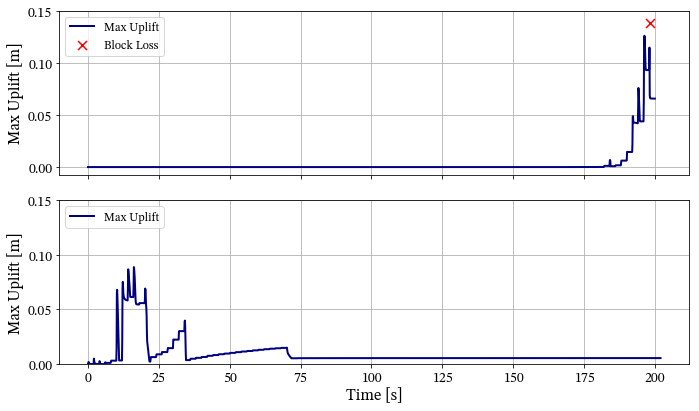

[198.2]


In [27]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Matplotlib styling ---
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams["font.family"] = "STIX Two Text"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.size"] = 16  # base font size for labels/titles

# --- Settings ---
fly_out_value = 0.151

csv_path1 = 'relative_uplift_timeseries_0_6_200_ASC_corrected.csv'
csv_path2 = 'relative_uplift_timeseries_06_200_corrected.csv'

def process_csv(csv_path):
    """Reads CSV, processes uplift data, and returns time, max uplift, and first loss times."""
    df_uplift = pd.read_csv(csv_path)

    # Detect time column automatically
    if df_uplift.columns[0].lower() == "step":
        time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
    else:
        time_col = df_uplift.columns[0]

    # Round times
    df_uplift[time_col] = df_uplift[time_col].round(2)

    # Identify block columns
    block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
    block_data_all = df_uplift[block_cols].copy()

    # Handle fly-out values
    fly_out_mask = (block_data_all == fly_out_value)
    block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)

    # Calculate max uplift at each time
    max_uplift = block_data_cleaned.max(axis=1)

    # Identify first loss times
    first_loss_times = []
    for col in block_cols:
        fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
        if fly_out_indices:
            first_idx = fly_out_indices[0]
            first_loss_times.append(df_uplift.loc[first_idx, time_col])
    first_loss_times = sorted(set(first_loss_times))

    return df_uplift[time_col], max_uplift, first_loss_times

# --- Process both CSVs ---
time1, max_uplift1, loss_times1 = process_csv(csv_path1)
time2, max_uplift2, loss_times2 = process_csv(csv_path2)

# --- Plot ---
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(10, 6),
    sharex=True
)

# Top subplot
axes[0].plot(time1, max_uplift1, color='navy', linewidth=2, label='Max Uplift')
if len(loss_times1) > 0:
    cross_y_value = max_uplift1.max() * 1.1 if max_uplift1.max() > 0 else 0.01
    axes[0].scatter(loss_times1, [cross_y_value] * len(loss_times1),
                    color='red', marker='x', s=80, label='Block Loss')
axes[0].set_ylabel("Max Uplift [m]", fontsize=16)
axes[0].legend(loc='upper left', fontsize=12)
axes[0].grid(True)
axes[0].tick_params(axis='both', which='major', labelsize=14)  # numbers smaller

# Bottom subplot
axes[1].plot(time2, max_uplift2, color='navy', linewidth=2, label='Max Uplift')
if len(loss_times2) > 0:
    cross_y_value = max_uplift2.max() * 1.1 if max_uplift2.max() > 0 else 0.01
    axes[1].scatter(loss_times2, [cross_y_value] * len(loss_times2),
                    color='red', marker='x', s=80, label='Block Loss')
axes[1].set_xlabel("Time [s]", fontsize=16)
axes[1].set_ylabel("Max Uplift [m]", fontsize=16)
axes[1].set_ylim(0, 0.150)
axes[1].legend(loc='upper left', fontsize=12)
axes[1].grid(True)
axes[1].tick_params(axis='both', which='major', labelsize=14)  # numbers smaller

plt.tight_layout()
plt.savefig("relative_uplift_timeseries_asc.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(loss_times1)


In [33]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import os

# ------------------------------
# CONFIGURATION
# ------------------------------

run_name = "0_6_200_ASC"
csv_path = f"relative_uplift_timeseries_{run_name}_corrected.csv"

times_to_check = list(np.arange(180.5, 200, 2.0))
D = 0.15  # block diameter in meters

# Define damage category thresholds
damage_thresholds = [
    (0.01, 0.33, 1),
    (0.33, 0.67, 2),
    (0.67, 1.0, 3),
    (1.0, float('inf'), 4)
]

# ------------------------------
# ANALYSIS
# ------------------------------

if not os.path.exists(csv_path):
    print(f"⛔ CSV file not found: {csv_path}")
else:
    df_uplift = pd.read_csv(csv_path)

    # Detect time column automatically
    if df_uplift.columns[0].lower() == "step":
        time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
    else:
        time_col = df_uplift.columns[0]

    # Round time for matching
    df_uplift[time_col] = df_uplift[time_col].round(2)

    # Extract block columns (those starting with "B-")
    block_cols = [c for c in df_uplift.columns if c.startswith("B-")]

    if not block_cols:
        print(f"⛔ CSV: No block columns found in {csv_path}.")
    else:
        for target_time in times_to_check:
            # Find the row at the desired time
            row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]

            if row_df.empty:
                print(f"⛔ CSV: Time step {target_time:.2f} s not found in {csv_path}. Skipping.")
                continue

            block_data = row_df[block_cols].iloc[0]

            # KEEP fly-out values so they count as damage
            uplift_values = block_data.values
            ze_over_D = uplift_values / D

            # Count damage categories
            damage_counts = {cat: 0 for _, _, cat in damage_thresholds}

            for val_norm in ze_over_D:
                if np.isnan(val_norm) or val_norm <= 0:
                    continue
                for lower, upper, cat in damage_thresholds:
                    if lower < val_norm <= upper:
                        damage_counts[cat] += 1
                        break

            # Print damage summary
            print(f"\n✅ Damage summary for {run_name} at t = {target_time:.2f} s:")
            for cat in [1, 2, 3, 4]:
                print(f"Damage category {cat}: {damage_counts[cat]} blocks")



✅ Damage summary for 0_6_200_ASC at t = 180.50 s:
Damage category 1: 0 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

✅ Damage summary for 0_6_200_ASC at t = 182.50 s:
Damage category 1: 0 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

✅ Damage summary for 0_6_200_ASC at t = 184.50 s:
Damage category 1: 0 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

✅ Damage summary for 0_6_200_ASC at t = 186.50 s:
Damage category 1: 1 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

✅ Damage summary for 0_6_200_ASC at t = 188.50 s:
Damage category 1: 1 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

✅ Damage summary for 0_6_200_ASC at t = 190.50 s:
Damage category 1: 4 blocks
Damage category 2: 0 blocks
Damage category 3: 0 blocks
Damage category 4: 0 blocks

✅ Damage summary for 

In [38]:
import numpy as np
import pandas as pd

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

results = []

for Hs in [0.6, 0.7, 0.8]:

    sigma = Hs / np.sqrt(2.0)
    # take the 100 largest waves in 1000
    exceed_probs = np.arange(1, 101, 1) / 1000.0
    wave_heights = sigma * np.sqrt(-2.0 * np.log(exceed_probs))

    for i, H_wave in enumerate(wave_heights):
        Tm_1_0 = Tp / 1.1
        L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
        xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
        z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3.0 else np.nan
        x_center = (SWL - z_SWL) / tan_beta

        w_base = (7.0 / 6.0) * H_wave
        w_top = (1.0 / 3.0) * H_wave
        x_left_base = x_center - w_base / 2.0
        x_right_base = x_center + w_base / 2.0
        x_left_top = x_center - w_top / 2.0
        x_right_top = x_center + w_top / 2.0

        denom = (xi - 0.2)**2
        P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
        P_max = P_dimless * rho_w * g * H_wave

        p_vals = np.zeros_like(x)
        for j, xx in enumerate(x):
            if x_left_base <= xx < x_left_top:
                p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
            elif x_left_top <= xx <= x_right_top:
                p_vals[j] = P_max
            elif x_right_top < xx <= x_right_base:
                p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

        b_vec = -p_vals.copy()
        b_vec[0] = b_vec[-1] = 0.0
        A = np.zeros((N, N))
        coeff = Lambda**2 / dx**2
        for j in range(1, N - 1):
            A[j, j - 1] = coeff
            A[j, j] = -2.0 * coeff - 1.0
            A[j, j + 1] = coeff
        A[0, 0] = A[-1, -1] = 1.0
        phi_F = np.linalg.solve(A, b_vec)
        residual = phi_F - p_vals

        max_residual = np.max(residual)

        results.append({
            "Hs": Hs,
            "Wave_rank": f"{i+1}/1000",
            "H_wave": H_wave,
            "Max_residual_pressure_Pa": max_residual
        })

# Export to CSV
df = pd.DataFrame(results)
df.to_csv("max_pressure_per_wave.csv", index=False)

print("✅ Saved max pressure table to max_pressure_per_wave.csv")
print(df)


✅ Saved max pressure table to max_pressure_per_wave.csv
       H_wave   Hs  Max_residual_pressure_Pa Wave_rank
0    1.576957  0.6              18126.244161    1/1000
1    1.495747  0.6              17211.341801    2/1000
2    1.446130  0.6              16556.929036    3/1000
3    1.409867  0.6              16212.459184    4/1000
4    1.381084  0.6              15865.972511    5/1000
5    1.357114  0.6              15558.281375    6/1000
6    1.336512  0.6              15212.930815    7/1000
7    1.318405  0.6              15043.946019    8/1000
8    1.302225  0.6              14841.294988    9/1000
9    1.287580  0.6              14633.907449   10/1000
10   1.274186  0.6              14379.273703   11/1000
11   1.261834  0.6              14342.796292   12/1000
12   1.250364  0.6              14158.819358   13/1000
13   1.239650  0.6              14049.088341   14/1000
14   1.229591  0.6              13904.553350   15/1000
15   1.220107  0.6              13723.800254   16/1000
16   1.21

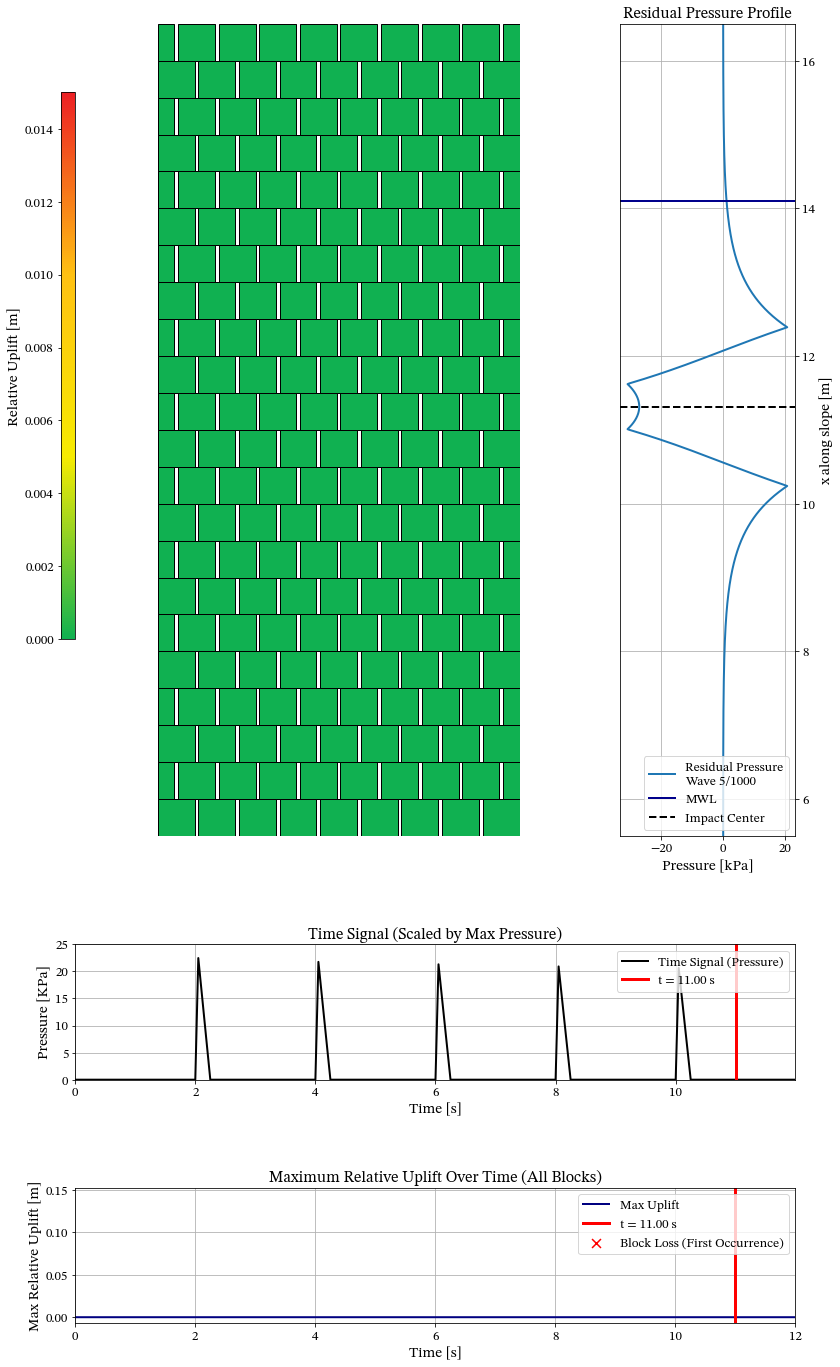

✅ Finished plotting block grid with uplift and residual pressure (saved as PDF).
Wave 1: Max residual pressure = 22463.65 Pa
Wave 2: Max residual pressure = 21760.51 Pa
Wave 3: Max residual pressure = 21309.84 Pa
Wave 4: Max residual pressure = 20919.28 Pa
Wave 5: Max residual pressure = 20630.06 Pa


In [39]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve

# ------------------------------
# Global font settings
# ------------------------------
plt.rcParams['font.family'] = 'STIX Two Text'  # Use STIX Two Text font
plt.rcParams['mathtext.fontset'] = 'stix'      # Ensure math matches STIX
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['figure.titlesize'] = 18

# --- Settings ---
fly_out_value = 0.151
target_time = 11   # time in seconds to visualize
csv_path = 'relative_uplift_timeseries_0_6_200_ASC_corrected.csv'
df_uplift = pd.read_csv(csv_path)
Hs = 0.8

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0
grid_width = (9 * full_w) + (8 * horizontal_spacing)
rows = 22

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]
df_uplift[time_col] = df_uplift[time_col].round(2)

# Extract data for plotting the block grid
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]
if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")
block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
block_data = row_df[block_cols].iloc[0]

# Normalize color for uplift values
norm = plt.Normalize(vmin=0, vmax=0.015)
colors = ["#10b151", "#f6eb01", "#ffc112", "#ed2024"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)
no_data_color = "lightgray"

# ------------------------------
# Time signal setup
# ------------------------------
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])
total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01
end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

# Load max residual pressure table
df_max_press = pd.read_csv("max_pressure_per_wave.csv")
df_max_press_Hs = df_max_press[df_max_press["Hs"] == Hs].reset_index(drop=True)

signal_scaled = np.zeros_like(time_signal)
for wave_idx in range(total_waves):
    if wave_idx < len(df_max_press_Hs):
        max_press = df_max_press_Hs.loc[wave_idx, "Max_residual_pressure_Pa"]
    else:
        max_press = 0.0
    t_start = gravity_time + wave_idx * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal_scaled[active] = pulse * max_press

df_signal = pd.DataFrame({"Time": time_signal, "Signal": signal_scaled})

# ------------------------------
# Simulate residual profiles
# ------------------------------
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

# Determine active wave
active_wave = None
for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break
if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = list(residual_profiles.keys())[0]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

# ------------------------------
# Plotting
# ------------------------------
fig = plt.figure(figsize=(10, 19))
gs = gridspec.GridSpec(
    nrows=3, ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1, 1],
    wspace=0.05,
    hspace=0.3
)

# --- Top left: block grid ---
ax_grid = fig.add_subplot(gs[0, 0])
for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [(full_w, f"B-{row_num}-{col}") for col in range(1, 10)]
    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            color = no_data_color if np.isnan(value) else cmap(norm(value))
        else:
            color = no_data_color
        rect = patches.Rectangle((x_pos, current_y), block_w, full_h,
                                 edgecolor='black', facecolor=color, linewidth=1)
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing
ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift [m]')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])
residual_vals_kPa = residual_vals / 1000.0
ax_side.plot(residual_vals_kPa, x, color='#1f77b4', linewidth=2, label=f"Residual Pressure\nWave 5/1000")
ax_side.axhline(x_mwl, color='darkblue', linestyle='-', linewidth=2, label='MWL')
ax_side.axhline(x_center, color='black', linestyle='--', linewidth=2, label='Impact Center')
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right')

# --- Middle: scaled time signal ---
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(df_signal["Time"], df_signal["Signal"]/1000, color='black', linewidth=2, label='Time Signal (Pressure)')
ax_bottom.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.2f} s")
ax_bottom.set_xlim(0, df_signal["Time"].iloc[-1])
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Pressure [KPa]')
ax_bottom.set_ylim(0, 25)
ax_bottom.grid(True)
ax_bottom.set_title('Time Signal (Scaled by Max Pressure)')
ax_bottom.legend(loc='upper right')

# --- Bottom: max uplift over time ---
ax_uplift = fig.add_subplot(gs[2, :])
block_data_all = df_uplift[block_cols].copy()
fly_out_mask = (block_data_all == fly_out_value)
block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)
max_uplift = block_data_cleaned.max(axis=1)

first_loss_times = []
for col in block_cols:
    fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
    if fly_out_indices:
        first_idx = fly_out_indices[0]
        first_loss_times.append(df_uplift.loc[first_idx, time_col])
first_loss_times = sorted(set(first_loss_times))

ax_uplift.plot(df_uplift[time_col], max_uplift, color='navy', linewidth=2, label='Max Uplift')
ax_uplift.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.2f} s")
if len(first_loss_times) > 0:
    cross_y_value = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
    ax_uplift.scatter(first_loss_times, [cross_y_value] * len(first_loss_times),
                      color='red', marker='x', s=80, label='Block Loss (First Occurrence)')
ax_uplift.set_xlabel("Time [s]")
ax_uplift.set_xlim(0, 12)
ax_uplift.set_ylabel("Max Relative Uplift [m]")
ax_uplift.set_title("Maximum Relative Uplift Over Time (All Blocks)")
ax_uplift.legend(loc='upper right')
ax_uplift.grid(True)

# Save as PDF
plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.show()
# fig.savefig(csv_path.replace(".csv", ".pdf"), dpi=300, bbox_inches='tight')
print("✅ Finished plotting block grid with uplift and residual pressure (saved as PDF).")

signal_scaled = np.zeros_like(time_signal)
for wave_idx in range(total_waves):
    if wave_idx < len(df_max_press_Hs):
        max_press = df_max_press_Hs.loc[wave_idx, "Max_residual_pressure_Pa"]
    else:
        max_press = 0.0
    print(f"Wave {wave_idx+1}: Max residual pressure = {max_press:.2f} Pa")  # 🔹 Added line
    t_start = gravity_time + wave_idx * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal_scaled[active] = pulse * max_press


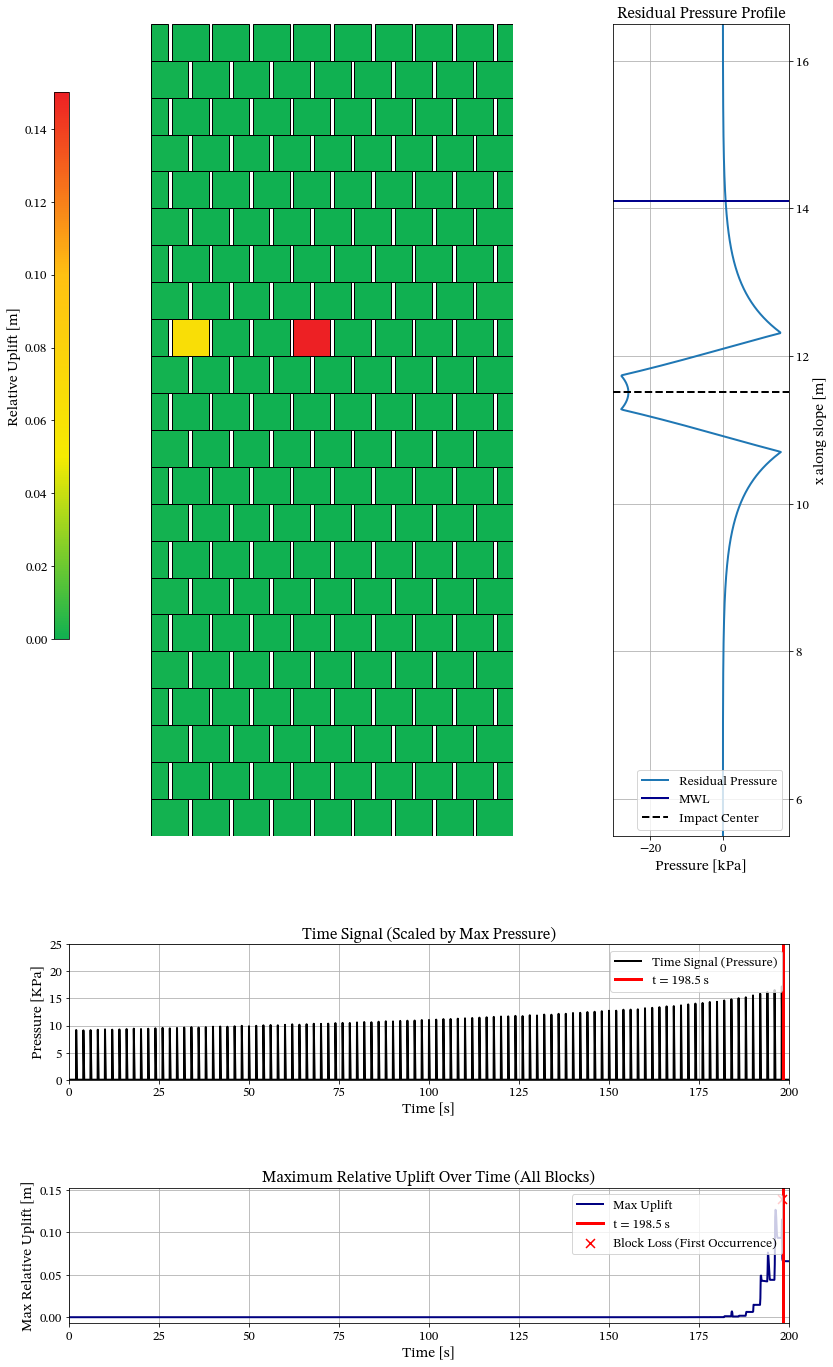

In [60]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve

# Global font settings
plt.rcParams['font.family'] = 'STIX Two Text'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['figure.titlesize'] = 18

# --- Settings ---
fly_out_value = 0.151
target_time = 198.5
csv_path = 'relative_uplift_timeseries_0_6_200_ASC_corrected.csv'
df_uplift = pd.read_csv(csv_path)
Hs = 0.6

# Brick layout
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0
grid_width = (9 * full_w) + (8 * horizontal_spacing)
rows = 22

# Time column
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]
df_uplift[time_col] = df_uplift[time_col].round(2)

# Extract target row
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]
if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")
block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
block_data_raw = row_df[block_cols].iloc[0]

# Shift block data one to the right
block_data = block_data_raw.copy()
for row in range(1, 23):
    prefix = f"B-{row}-"
    if row % 2 == 1:
        keys = [f"{prefix}{i}" for i in range(1, 11)]
    else:
        keys = [f"{prefix}{i}" for i in range(1, 10)]
    shifted = [0.001] + [block_data_raw.get(k, np.nan) for k in keys[:-1]]
    for k, v in zip(keys, shifted):
        block_data[k] = v

# Color settings
norm = plt.Normalize(vmin=0, vmax=0.150)
colors = ["#10b151", "#f6eb01", "#ffc112", "#ed2024"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)
no_data_color = "lightgray"

# Time signal setup
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01
total_waves = int((200 - gravity_time) / pulse_interval)
end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)
df_max_press = pd.read_csv("max_pressure_per_wave.csv")
df_max_press_Hs = df_max_press[df_max_press["Hs"] == Hs].reset_index(drop=True)

# Reversed wave order
signal_scaled = np.zeros_like(time_signal)
for wave_idx in range(total_waves):
    reversed_idx = len(df_max_press_Hs) - 1 - wave_idx
    if 0 <= reversed_idx < len(df_max_press_Hs):
        max_press = df_max_press_Hs.loc[reversed_idx, "Max_residual_pressure_Pa"]
    else:
        max_press = 0.0
    t_start = gravity_time + wave_idx * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal_scaled[active] = pulse * max_press
df_signal = pd.DataFrame({"Time": time_signal, "Signal": signal_scaled})

# --- Plotting ---
fig = plt.figure(figsize=(10, 19))
gs = gridspec.GridSpec(3, 2, width_ratios=[3, 1], height_ratios=[6, 1, 1], wspace=0.05, hspace=0.3)

# --- Top left: block grid ---
ax_grid = fig.add_subplot(gs[0, 0])
for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [(full_w, f"B-{row_num}-{col}") for col in range(1, 10)]
    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            color = no_data_color if np.isnan(value) else cmap(norm(value))
        else:
            color = no_data_color
        rect = patches.Rectangle((x_pos, current_y), block_w, full_h,
                                 edgecolor='black', facecolor=color, linewidth=1)
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing
ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift [m]')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])
residual_vals_kPa = residual_vals / 1000.0
ax_side.plot(residual_vals_kPa, x, color='#1f77b4', linewidth=2, label="Residual Pressure")
ax_side.axhline(x_mwl, color='darkblue', linestyle='-', linewidth=2, label='MWL')
ax_side.axhline(x_center, color='black', linestyle='--', linewidth=2, label='Impact Center')
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right')

# --- Middle: scaled time signal (reversed wave order) ---
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(df_signal["Time"], df_signal["Signal"]/1000, color='black', linewidth=2, label='Time Signal (Pressure)')
ax_bottom.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.1f} s")
ax_bottom.set_xlim(0, 200)
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Pressure [KPa]')
ax_bottom.set_ylim(0, 25)
ax_bottom.grid(True)
ax_bottom.set_title('Time Signal (Scaled by Max Pressure)')
ax_bottom.legend(loc='upper right')

# --- Bottom: max uplift over time ---
ax_uplift = fig.add_subplot(gs[2, :])
block_data_all = df_uplift[block_cols].copy()
fly_out_mask = (block_data_all == fly_out_value)
block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)
max_uplift = block_data_cleaned.max(axis=1)

first_loss_times = []
for col in block_cols:
    fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
    if fly_out_indices:
        first_idx = fly_out_indices[0]
        first_loss_times.append(df_uplift.loc[first_idx, time_col])
first_loss_times = sorted(set(first_loss_times))

ax_uplift.plot(df_uplift[time_col], max_uplift, color='navy', linewidth=2, label='Max Uplift')
ax_uplift.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.1f} s")
if len(first_loss_times) > 0:
    cross_y_value = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
    ax_uplift.scatter(first_loss_times, [cross_y_value] * len(first_loss_times),
                      color='red', marker='x', s=80, label='Block Loss (First Occurrence)')
ax_uplift.set_xlabel("Time [s]")
ax_uplift.set_xlim(0, 200)
ax_uplift.set_ylabel("Max Relative Uplift [m]")
ax_uplift.set_title("Maximum Relative Uplift Over Time (All Blocks)")
ax_uplift.legend(loc='upper right')
ax_uplift.grid(True)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.savefig("200_ASC_3.pdf", bbox_inches='tight')
plt.show()


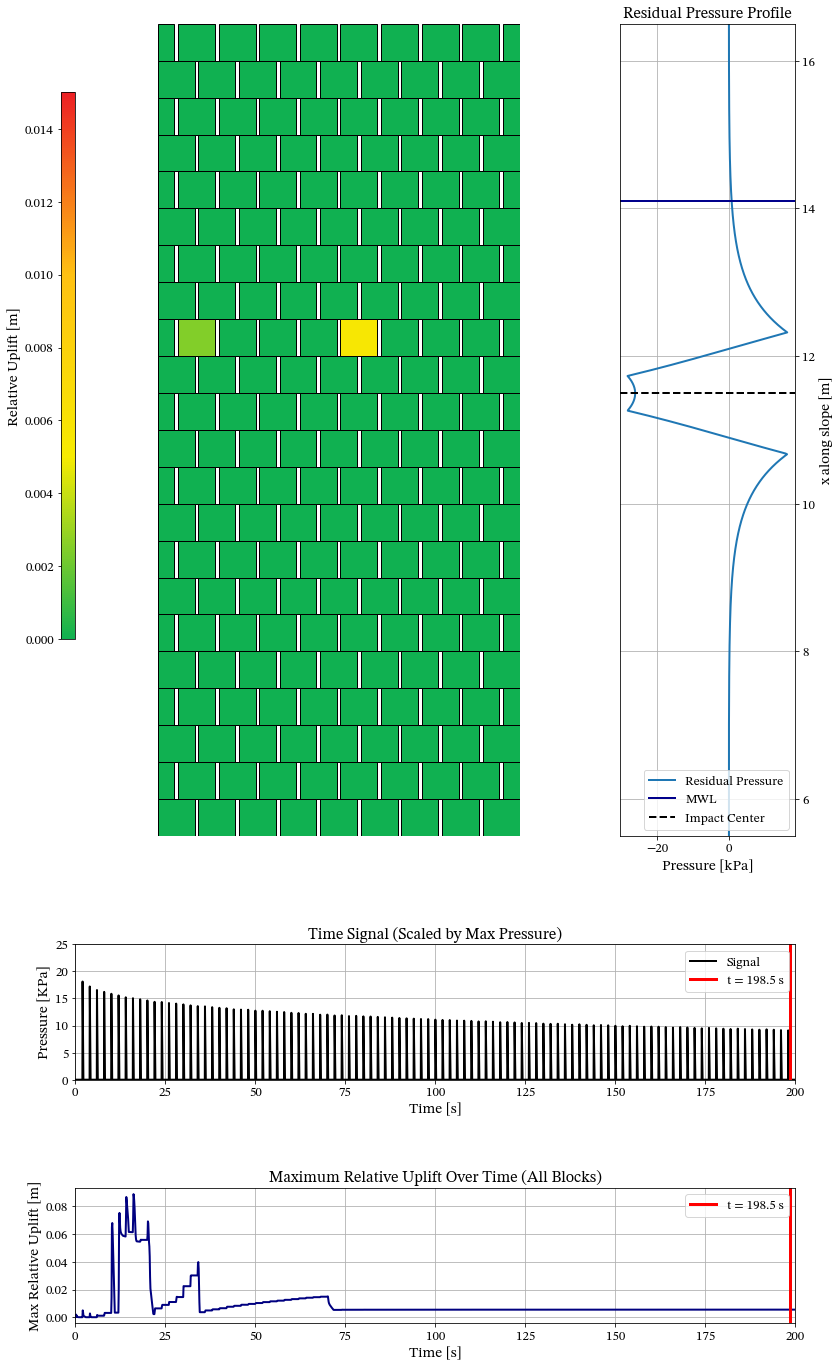

Wave 1: Max residual pressure = 18126.24 Pa
Wave 2: Max residual pressure = 17211.34 Pa
Wave 3: Max residual pressure = 16556.93 Pa
Wave 4: Max residual pressure = 16212.46 Pa
Wave 5: Max residual pressure = 15865.97 Pa
Wave 6: Max residual pressure = 15558.28 Pa
Wave 7: Max residual pressure = 15212.93 Pa
Wave 8: Max residual pressure = 15043.95 Pa
Wave 9: Max residual pressure = 14841.29 Pa
Wave 10: Max residual pressure = 14633.91 Pa
Wave 11: Max residual pressure = 14379.27 Pa
Wave 12: Max residual pressure = 14342.80 Pa
Wave 13: Max residual pressure = 14158.82 Pa
Wave 14: Max residual pressure = 14049.09 Pa
Wave 15: Max residual pressure = 13904.55 Pa
Wave 16: Max residual pressure = 13723.80 Pa
Wave 17: Max residual pressure = 13583.67 Pa
Wave 18: Max residual pressure = 13535.96 Pa
Wave 19: Max residual pressure = 13390.81 Pa
Wave 20: Max residual pressure = 13272.29 Pa
Wave 21: Max residual pressure = 13194.95 Pa
Wave 22: Max residual pressure = 12993.02 Pa
Wave 23: Max residu

In [56]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve

# ------------------------------
# Global font settings
# ------------------------------
plt.rcParams['font.family'] = 'STIX Two Text'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['figure.titlesize'] = 18

# --- Settings ---
fly_out_value = 0.151
target_time = 198.5
csv_path = 'relative_uplift_timeseries_06_200_corrected.csv'
df_uplift = pd.read_csv(csv_path)
Hs = 0.6

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0
grid_width = (9 * full_w) + (8 * horizontal_spacing)
rows = 22

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]
df_uplift[time_col] = df_uplift[time_col].round(2)

# Extract data for plotting the block grid
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]
if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")
block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
block_data = row_df[block_cols].iloc[0]

# Normalize color for uplift values
norm = plt.Normalize(vmin=0, vmax=0.0150)
colors = ["#10b151", "#f6eb01", "#ffc112", "#ed2024"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)
no_data_color = "lightgray"

# ------------------------------
# Time signal setup
# ------------------------------
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

total_waves = int((200 - gravity_time) / pulse_interval)
end_time = gravity_time + total_waves * pulse_interval
time_signal = np.arange(0, end_time, dt)

df_max_press = pd.read_csv("max_pressure_per_wave.csv")
df_max_press_Hs = df_max_press[df_max_press["Hs"] == Hs].reset_index(drop=True)

signal_scaled = np.zeros_like(time_signal)
for wave_idx in range(total_waves):
    max_press = df_max_press_Hs.loc[wave_idx, "Max_residual_pressure_Pa"] if wave_idx < len(df_max_press_Hs) else 0.0
    t_start = gravity_time + wave_idx * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal_scaled[active] = pulse * max_press

df_signal = pd.DataFrame({"Time": time_signal, "Signal": signal_scaled})

# ------------------------------
# Simulate residual profiles
# ------------------------------
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

# Determine active wave
active_wave = None
for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break
if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave % len(residual_profiles)]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = list(residual_profiles.keys())[0]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

# ------------------------------
# Plotting
# ------------------------------
fig = plt.figure(figsize=(10, 19))
gs = gridspec.GridSpec(3, 2, width_ratios=[3, 1], height_ratios=[6, 1, 1], wspace=0.05, hspace=0.3)

# --- Top left: block grid ---
ax_grid = fig.add_subplot(gs[0, 0])
for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [(full_w, f"B-{row_num}-{col}") for col in range(1, 10)]
    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            color = no_data_color if np.isnan(value) else cmap(norm(value))
        else:
            color = no_data_color
        rect = patches.Rectangle((x_pos, current_y), block_w, full_h,
                                 edgecolor='black', facecolor=color, linewidth=1)
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing
ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift [m]')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])
residual_vals_kPa = residual_vals / 1000.0
ax_side.plot(residual_vals_kPa, x, color='#1f77b4', linewidth=2, label="Residual Pressure")
ax_side.axhline(x_mwl, color='darkblue', linestyle='-', linewidth=2, label='MWL')
ax_side.axhline(x_center, color='black', linestyle='--', linewidth=2, label='Impact Center')
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right')

# --- Middle: scaled time signal ---
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(df_signal["Time"], df_signal["Signal"] / 1000, color='black', linewidth=2)
ax_bottom.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.1f} s")
ax_bottom.set_xlim(0, 200)
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Pressure [KPa]')
ax_bottom.set_ylim(0, 25)
ax_bottom.grid(True)
ax_bottom.set_title('Time Signal (Scaled by Max Pressure)')
ax_bottom.legend(loc='upper right')

# --- Bottom: max uplift over time ---
ax_uplift = fig.add_subplot(gs[2, :])
block_data_all = df_uplift[block_cols].copy()
fly_out_mask = (block_data_all == fly_out_value)
block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)
max_uplift = block_data_cleaned.max(axis=1)

first_loss_times = []
for col in block_cols:
    fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
    if fly_out_indices:
        first_loss_times.append(df_uplift.loc[fly_out_indices[0], time_col])
first_loss_times = sorted(set(first_loss_times))

ax_uplift.plot(df_uplift[time_col], max_uplift, color='navy', linewidth=2)
ax_uplift.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.1f} s")
if first_loss_times:
    cross_y = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
    ax_uplift.scatter(first_loss_times, [cross_y] * len(first_loss_times),
                      color='red', marker='x', s=80, label='Block Loss')
ax_uplift.set_xlabel("Time [s]")
ax_uplift.set_xlim(0, 200)
ax_uplift.set_ylabel("Max Relative Uplift [m]")
ax_uplift.set_title("Maximum Relative Uplift Over Time (All Blocks)")
ax_uplift.legend(loc='upper right')
ax_uplift.grid(True)

plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.savefig("200_ASC_2.pdf", bbox_inches='tight')
plt.show()

# Print pressure table
for wave_idx in range(total_waves):
    max_press = df_max_press_Hs.loc[wave_idx, "Max_residual_pressure_Pa"] if wave_idx < len(df_max_press_Hs) else 0.0
    print(f"Wave {wave_idx+1}: Max residual pressure = {max_press:.2f} Pa")


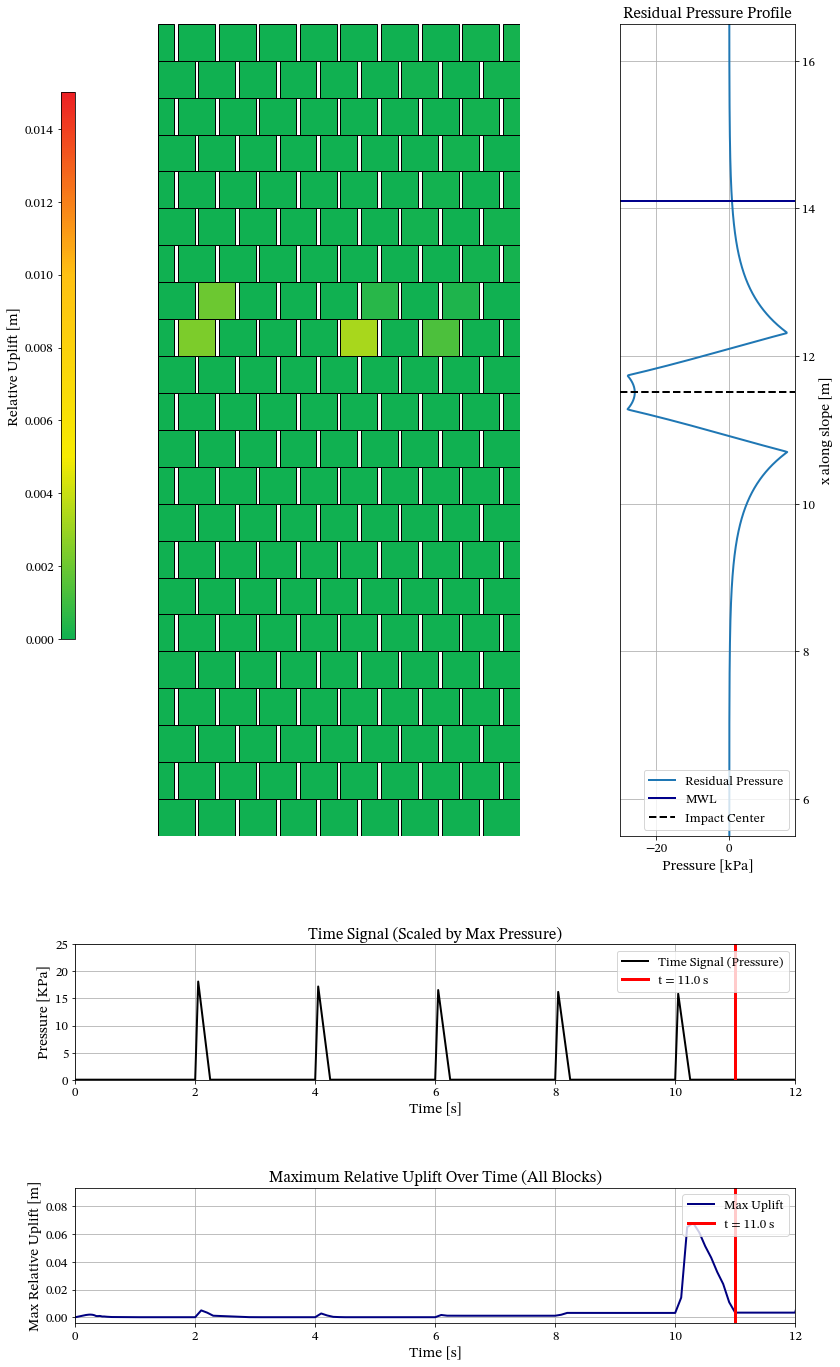

✅ Finished plotting block grid with uplift and residual pressure (saved as PDF).
Wave 1: Max residual pressure = 18126.24 Pa
Wave 2: Max residual pressure = 17211.34 Pa
Wave 3: Max residual pressure = 16556.93 Pa
Wave 4: Max residual pressure = 16212.46 Pa
Wave 5: Max residual pressure = 15865.97 Pa


In [58]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import solve

# ------------------------------
# Global font settings
# ------------------------------
plt.rcParams['font.family'] = 'STIX Two Text'  # Use STIX Two Text font
plt.rcParams['mathtext.fontset'] = 'stix'      # Ensure math matches STIX
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
plt.rcParams['figure.titlesize'] = 18

# --- Settings ---
fly_out_value = 0.151
target_time = 11.0   # focus time in seconds (within 0–12s range)
csv_path = 'relative_uplift_timeseries_06_200_corrected.csv'
df_uplift = pd.read_csv(csv_path)
Hs = 0.6

# ------------------------------
# Define brick layout parameters
# ------------------------------
full_w = 0.5
full_h = 0.5
half_w = 0.225
half_h = 0.5
horizontal_spacing = 0.05
v_spacing = 0.0
grid_width = (9 * full_w) + (8 * horizontal_spacing)
rows = 22

# Detect time column automatically
if df_uplift.columns[0].lower() == "step":
    time_col = "CumulativeTime" if "CumulativeTime" in df_uplift.columns else df_uplift.columns[1]
else:
    time_col = df_uplift.columns[0]
df_uplift[time_col] = df_uplift[time_col].round(2)

# Extract data for plotting the block grid
row_df = df_uplift[df_uplift[time_col] == round(target_time, 2)]
if row_df.empty:
    raise ValueError(f"⛔ Time step {target_time:.2f} not found in CSV.")
block_cols = [c for c in df_uplift.columns if c.startswith("B-")]
block_data = row_df[block_cols].iloc[0]

# Normalize color for uplift values
norm = plt.Normalize(vmin=0, vmax=0.0150)
colors = ["#10b151", "#f6eb01", "#ffc112", "#ed2024"]
cmap = LinearSegmentedColormap.from_list("uplift_cmap", colors, N=256)
no_data_color = "lightgray"

# ------------------------------
# Time signal setup
# ------------------------------
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])
pulse_duration = 0.25
pulse_interval = 2.0
gravity_time = 2.0
dt = 0.01

# compute how many waves needed to reach 12 s
end_time = 12.0
time_signal = np.arange(0, end_time, dt)
total_waves = int((end_time - gravity_time) / pulse_interval)

# Load max residual pressure table
df_max_press = pd.read_csv("max_pressure_per_wave.csv")
df_max_press_Hs = df_max_press[df_max_press["Hs"] == Hs].reset_index(drop=True)

signal_scaled = np.zeros_like(time_signal)
for wave_idx in range(total_waves):
    if wave_idx < len(df_max_press_Hs):
        max_press = df_max_press_Hs.loc[wave_idx, "Max_residual_pressure_Pa"]
    else:
        max_press = 0.0
    t_start = gravity_time + wave_idx * pulse_interval
    active = (time_signal >= t_start) & (time_signal <= t_start + pulse_duration)
    local_time = time_signal[active] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)
    signal_scaled[active] = pulse * max_press

df_signal = pd.DataFrame({"Time": time_signal, "Signal": signal_scaled})

# ------------------------------
# Simulate residual profiles
# ------------------------------
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

x_mwl = SWL / tan_beta
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

wave_pressures = {}
residual_profiles = {}
impact_centers = {}

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0 ** 2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda ** 2 / dx ** 2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    residual_profiles[wave_name] = residual
    wave_pressures[wave_name] = p_vals
    impact_centers[wave_name] = x_center

# Determine active wave
active_wave = None
for wave_idx in range(total_waves):
    t_start = gravity_time + wave_idx * pulse_interval
    t_end = gravity_time + (wave_idx + 1) * pulse_interval
    if t_start <= target_time < t_end:
        active_wave = wave_idx
        break
if active_wave is not None:
    wave_name = list(residual_profiles.keys())[active_wave % len(residual_profiles)]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]
else:
    wave_name = list(residual_profiles.keys())[0]
    residual_vals = residual_profiles[wave_name]
    x_center = impact_centers[wave_name]

# ------------------------------
# Plotting
# ------------------------------
fig = plt.figure(figsize=(10, 19))
gs = gridspec.GridSpec(
    nrows=3, ncols=2,
    width_ratios=[3, 1],
    height_ratios=[6, 1, 1],
    wspace=0.05,
    hspace=0.3
)

# --- Top left: block grid ---
ax_grid = fig.add_subplot(gs[0, 0])
for row_num in range(1, rows + 1):
    current_y = (rows - row_num) * (full_h + v_spacing)
    is_half = (row_num % 2 == 1)
    if is_half:
        block_sequence = (
            [(half_w, f"B-{row_num}-1")] +
            [(full_w, f"B-{row_num}-{col}") for col in range(2, 10)] +
            [(half_w, f"B-{row_num}-10")]
        )
    else:
        block_sequence = [(full_w, f"B-{row_num}-{col}") for col in range(1, 10)]
    x_pos = 0.0
    for block_w, block_name in block_sequence:
        if block_name in block_data:
            value = block_data[block_name]
            color = no_data_color if np.isnan(value) else cmap(norm(value))
        else:
            color = no_data_color
        rect = patches.Rectangle((x_pos, current_y), block_w, full_h,
                                 edgecolor='black', facecolor=color, linewidth=1)
        ax_grid.add_patch(rect)
        x_pos += block_w + horizontal_spacing
ax_grid.set_aspect('equal')
ax_grid.set_xlim(0, grid_width)
ax_grid.set_ylim(0, rows * full_h)
ax_grid.axis('off')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([-0.02, 0.5, 0.02, 0.4])
cbar = plt.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Relative Uplift [m]')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_ticks_position('left')

# --- Top right: residual pressure profile ---
ax_side = fig.add_subplot(gs[0, 1])
residual_vals_kPa = residual_vals / 1000.0
ax_side.plot(residual_vals_kPa, x, color='#1f77b4', linewidth=2, label=f"Residual Pressure")
ax_side.axhline(x_mwl, color='darkblue', linestyle='-', linewidth=2, label='MWL')
ax_side.axhline(x_center, color='black', linestyle='--', linewidth=2, label='Impact Center')
ax_side.invert_yaxis()
ax_side.set_xlabel('Pressure [kPa]')
ax_side.set_ylabel('x along slope [m]')
ax_side.set_ylim(5.5, 16.5)
ax_side.yaxis.tick_right()
ax_side.yaxis.set_label_position("right")
ax_side.set_title("Residual Pressure Profile")
ax_side.grid(True)
ax_side.legend(loc='lower right')

# --- Middle: scaled time signal ---
ax_bottom = fig.add_subplot(gs[1, :])
ax_bottom.plot(df_signal["Time"], df_signal["Signal"]/1000, color='black', linewidth=2, label='Time Signal (Pressure)')
ax_bottom.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.1f} s")
ax_bottom.set_xlim(0, 12)
ax_bottom.set_xlabel('Time [s]')
ax_bottom.set_ylabel('Pressure [KPa]')
ax_bottom.set_ylim(0, 25)
ax_bottom.grid(True)
ax_bottom.set_title('Time Signal (Scaled by Max Pressure)')
ax_bottom.legend(loc='upper right')

# --- Bottom: max uplift over time ---
ax_uplift = fig.add_subplot(gs[2, :])
block_data_all = df_uplift[block_cols].copy()
fly_out_mask = (block_data_all == fly_out_value)
block_data_cleaned = block_data_all.replace(fly_out_value, np.nan)
max_uplift = block_data_cleaned.max(axis=1)

first_loss_times = []
for col in block_cols:
    fly_out_indices = fly_out_mask.index[fly_out_mask[col]].tolist()
    if fly_out_indices:
        first_idx = fly_out_indices[0]
        first_loss_times.append(df_uplift.loc[first_idx, time_col])
first_loss_times = sorted(set(first_loss_times))

ax_uplift.plot(df_uplift[time_col], max_uplift, color='navy', linewidth=2, label='Max Uplift')
ax_uplift.axvline(target_time, color='red', linestyle='-', linewidth=3, label=f"t = {target_time:.1f} s")
if len(first_loss_times) > 0:
    cross_y_value = max_uplift.max() * 1.1 if max_uplift.max() > 0 else 0.01
    ax_uplift.scatter(first_loss_times, [cross_y_value] * len(first_loss_times),
                      color='red', marker='x', s=80, label='Block Loss (First Occurrence)')
ax_uplift.set_xlabel("Time [s]")
ax_uplift.set_xlim(0, 12)
ax_uplift.set_ylabel("Max Relative Uplift [m]")
ax_uplift.set_title("Maximum Relative Uplift Over Time (All Blocks)")
ax_uplift.legend(loc='upper right')
ax_uplift.grid(True)

# Save as PDF
plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0, hspace=0)
plt.savefig("200_ASC_1.pdf", bbox_inches='tight')
plt.show()

# fig.savefig(csv_path.replace(".csv", ".pdf"), dpi=300, bbox_inches='tight')
print("✅ Finished plotting block grid with uplift and residual pressure (saved as PDF).")

# Report wave pressures
for wave_idx in range(total_waves):
    if wave_idx < len(df_max_press_Hs):
        max_press = df_max_press_Hs.loc[wave_idx, "Max_residual_pressure_Pa"]
    else:
        max_press = 0.0
    print(f"Wave {wave_idx+1}: Max residual pressure = {max_press:.2f} Pa")
